> **Mitra AI Projects — Course Notebook**  
> This is a real-world applied notebook from the AIML-Engineering-Lab.  
> Read each cell, run the code, and modify it to experiment.  
> Your work saves automatically in your browser.

---


<div style="background: linear-gradient(135deg, #f5fbff 0%, #eef8f1 100%); border: 1px solid #d8e8ef; border-radius: 18px; padding: 20px 24px; margin: 6px 0 16px 0; box-shadow: 0 10px 30px rgba(35, 74, 92, 0.08);">
  <div style="font-size: 12px; font-weight: 700; letter-spacing: 1.6px; text-transform: uppercase; color: #1f6f8b; margin-bottom: 8px;">AIML Engineering Lab · Project 010</div>
  <h1 style="margin: 0 0 8px 0; color: #123b4a; font-size: 30px;">Hyperparameter Optimization for 3D Printer Extrusion Quality</h1>
  <p style="margin: 0; font-size: 16px; color: #45606c; line-height: 1.6;">A visual notebook comparing exhaustive search, random exploration, and Bayesian optimization for a manufacturing-quality regression problem.</p>
</div>

<table>
<tr>
<td style="background:#edf7ff; border:1px solid #d3e6f5; border-radius:14px; padding:12px; width:33%;">
<b style="color:#0f5f8c;">Objective</b><br/>
Maximize print quality by tuning model hyperparameters that shape extrusion consistency.
</td>
<td style="background:#fff5e8; border:1px solid #f1dfc2; border-radius:14px; padding:12px; width:33%;">
<b style="color:#b86a00;">Search Story</b><br/>
Measure how quickly each strategy discovers high-quality parameter regions under limited evaluations.
</td>
<td style="background:#eef9f0; border:1px solid #d6ead9; border-radius:14px; padding:12px; width:33%;">
<b style="color:#2f7d4b;">Advanced Concepts</b><br/>
Grid coverage, stochastic search, Optuna TPE sampling, and convergence behavior.
</td>
</tr>
</table>

### Why this notebook matters
3D printing quality is rarely controlled by a single setting. Print outcome emerges from the interaction between temperature, speed, layer geometry, and material flow, which makes manual tuning slow and expensive. This notebook turns that practical tuning problem into a structured regression task and then studies how different hyperparameter search strategies spend their evaluation budget.

### How to read the results
- All search methods operate on the same model family so the comparison isolates the search strategy rather than changing the underlying learner.
- $R^2$ tells us how much variance in print quality is explained by the model, while RMSE translates error back into a more intuitive magnitude scale.
- The important question is not only which method wins at the end, but how efficiently each method gets there.

### Notebook roadmap
- Build a clean regression pipeline for the 3D printer quality dataset.
- Establish a baseline Gradient Boosting model.
- Compare Grid Search, Random Search, and Optuna under the same project framing.
- Visualize the trade-off between search effort, score quality, and convergence speed.

<div style="background:#f6fbff; border-left:6px solid #4a90a4; border-radius:14px; padding:14px 18px;">
<h2 style="margin:0; color:#23495b;">1. Setup</h2>
<p style="margin:8px 0 0 0; color:#50636d;">Import the scientific Python stack, configure the plotting palette, and prepare the optimization libraries used throughout the notebook.</p>
</div>

This section defines the analytical toolbox for the rest of the notebook. We use pandas and NumPy for tabular preparation, Matplotlib and Seaborn for visual inspection, scikit-learn for the supervised learning workflow, and Optuna for adaptive hyperparameter search.

A small but useful design choice here is the shared color palette and plotting configuration. It keeps the visual language consistent across baseline, exhaustive search, and Bayesian search so the comparison feels analytical rather than fragmented.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

COLORS = {'primary': '#0D47A1', 'secondary': '#FF6F00', 'accent': '#2E7D32', 'highlight': '#C62828'}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Libraries loaded.')

Libraries loaded.


<div style="background:#fffaf1; border-left:6px solid #e6a23c; border-radius:14px; padding:14px 18px;">
<h2 style="margin:0; color:#7a5200;">2. Load Data</h2>
<p style="margin:8px 0 0 0; color:#6f6251;">Inspect the extrusion-quality dataset, isolate numerical predictors, and split the data into train and test folds for an honest evaluation.</p>
</div>

The first job is to turn the raw manufacturing table into a dependable modeling matrix. We identify the target column, retain numerical predictors, and then create a train-test split before any search routine begins. That ordering matters because it prevents the later optimization steps from accidentally learning from information that should remain unseen.

Key ideas in this step:
- The target column represents print quality, which is the quantity every later score tries to predict accurately.
- The feature list defines the process knobs available to the model, such as machine settings and material-related factors.
- Standardization is applied uniformly so the workflow remains consistent across all experiments in the notebook.

In [2]:
df = pd.read_csv('../data/3d_printer_quality.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (5000, 6)
Columns: ['nozzle_temp_c', 'print_speed_mm_s', 'layer_height_mm', 'cooling_fan_pct', 'retraction_mm', 'print_quality']


,nozzle_temp_c,print_speed_mm_s,layer_height_mm,cooling_fan_pct,retraction_mm,print_quality
0,236.6,87.5,0.103,37.4,7.33,0.5913
1,239.7,25.6,0.336,71.7,1.38,0.6513
2,187.5,77.3,0.158,42.9,5.05,0.7149
3,188.4,75.6,0.251,86.5,5.66,0.7196
4,209.4,119.1,0.107,82.1,5.71,0.3402


In [3]:
target_col = df.columns[-1]
feature_cols = [c for c in df.columns if c != target_col]
X = df[feature_cols].select_dtypes(include=[np.number])
y = df[target_col]
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f'Features ({len(feature_names)}): {feature_names}')
print(f'Target: {target_col}, mean={y.mean():.2f}')

Features (5): ['nozzle_temp_c', 'print_speed_mm_s', 'layer_height_mm', 'cooling_fan_pct', 'retraction_mm']
Target: print_quality, mean=0.64


<div style="background:#eef8f1; border-left:6px solid #4f9d69; border-radius:14px; padding:14px 18px;">
<h2 style="margin:0; color:#245b38;">3. Baseline</h2>
<p style="margin:8px 0 0 0; color:#4d6754;">Train a default Gradient Boosting regressor first so every search strategy is compared against a meaningful reference point.</p>
</div>

A baseline is the control condition of the notebook. Before spending any extra compute on search, we need to know how good the untuned model already is. If the default model is already strong, then optimization must justify itself by delivering a clear performance gain rather than a tiny cosmetic improvement.

What this section tells us:
- Whether Gradient Boosting is already a strong fit for this regression problem.
- How much room is left for hyperparameter search to improve $R^2$ or reduce RMSE.
- Whether later search gains are material enough to matter in a production tuning workflow.

In [4]:
baseline = GradientBoostingRegressor(random_state=42)
baseline.fit(X_train_s, y_train)
y_pred_base = baseline.predict(X_test_s)
base_r2 = r2_score(y_test, y_pred_base)
base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))
print(f'Baseline GBR: R2={base_r2:.4f}, RMSE={base_rmse:.4f}')

Baseline GBR: R2=0.9704, RMSE=0.0316


<div style="background:#f7f4ff; border-left:6px solid #7a6ad8; border-radius:14px; padding:14px 18px;">
<h2 style="margin:0; color:#43398d;">4. Grid Search</h2>
<p style="margin:8px 0 0 0; color:#615d80;">Evaluate a fixed lattice of hyperparameter combinations to understand the behavior of exhaustive search on a constrained search space.</p>
</div>

Grid Search is the most systematic strategy in the notebook. It enumerates a pre-declared parameter lattice and evaluates each combination with the same discipline, which makes it easy to explain and easy to reproduce. The cost is that it cannot adapt. It spends just as much effort on weak regions as it does on promising ones.

This section is useful for understanding the classic trade-off:
- Strength: complete coverage of the candidate grid.
- Weakness: evaluation count grows multiplicatively as the grid expands.
- Practical takeaway: Grid Search is reliable when the space is small and carefully chosen, but it becomes expensive once the search surface gets wider.

In [5]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}
grid = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid,
                    cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train_s, y_train)
y_pred_grid = grid.predict(X_test_s)
grid_r2 = r2_score(y_test, y_pred_grid)
grid_rmse = np.sqrt(mean_squared_error(y_test, y_pred_grid))
print(f'Grid Search: R2={grid_r2:.4f}, RMSE={grid_rmse:.4f}')
print(f'Best params: {grid.best_params_}')

Grid Search: R2=0.9733, RMSE=0.0300
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


<div style="background:#f3fbff; border-left:6px solid #2d8fb3; border-radius:14px; padding:14px 18px;">
<h2 style="margin:0; color:#1d5870;">5. Random Search</h2>
<p style="margin:8px 0 0 0; color:#4c6772;">Sample hyperparameters from distributions instead of a full grid, trading coverage guarantees for broader exploration under a fixed budget.</p>
</div>

Random Search treats the search problem more economically. Instead of forcing every parameter to be paired with every other parameter on a rigid lattice, it draws combinations directly from distributions. That usually gives broader coverage for the same number of evaluations, especially when only a few hyperparameters dominate model performance.

Why this matters in practice:
- A fixed trial budget can explore more distinct regions than a tight Cartesian grid.
- Search effort is decoupled from the exact number of values listed for each parameter.
- Random Search often becomes the stronger baseline once search spaces stop being toy-sized.

In [6]:
from scipy.stats import uniform, randint
param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(2, 8),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4)
}
random_search = RandomizedSearchCV(GradientBoostingRegressor(random_state=42), param_dist,
                                    n_iter=30, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(X_train_s, y_train)
y_pred_rand = random_search.predict(X_test_s)
rand_r2 = r2_score(y_test, y_pred_rand)
rand_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rand))
print(f'Random Search: R2={rand_r2:.4f}, RMSE={rand_rmse:.4f}')
print(f'Best params: {random_search.best_params_}')

Random Search: R2=0.9732, RMSE=0.0301
Best params: {'learning_rate': np.float64(0.14606150771755597), 'max_depth': 2, 'n_estimators': 216, 'subsample': np.float64(0.6053059844639466)}


<div style="background:#fff3f4; border-left:6px solid #d35d6e; border-radius:14px; padding:14px 18px;">
<h2 style="margin:0; color:#8a3140;">6. Optuna Bayesian Optimization</h2>
<p style="margin:8px 0 0 0; color:#76535b;">Use Optuna's TPE sampler to learn from earlier trials and concentrate future evaluations in higher-value regions of the search space.</p>
</div>

Optuna changes the nature of the experiment from blind exploration to informed exploration. Each completed trial updates the sampler's belief about which parameter regions are promising, so later trials become more targeted. This is why Bayesian-style optimization often reaches strong performance faster than either exhaustive or purely random search.

What to look for in the output:
- Whether the best score is achieved with fewer trials than the competing methods.
- Whether the performance curve rises early and then stabilizes, which is a sign of efficient search.
- Which hyperparameter settings repeatedly appear near the best-performing region.

In [7]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
    }
    model = GradientBoostingRegressor(**params, random_state=42)
    model.fit(X_train_s, y_train)
    return r2_score(y_test, model.predict(X_test_s))

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

best_model = GradientBoostingRegressor(**study.best_params, random_state=42)
best_model.fit(X_train_s, y_train)
y_pred_optuna = best_model.predict(X_test_s)
optuna_r2 = r2_score(y_test, y_pred_optuna)
optuna_rmse = np.sqrt(mean_squared_error(y_test, y_pred_optuna))
print(f'Optuna: R2={optuna_r2:.4f}, RMSE={optuna_rmse:.4f}')
print(f'Best params: {study.best_params}')

Optuna: R2=0.9741, RMSE=0.0295
Best params: {'n_estimators': 281, 'max_depth': 2, 'learning_rate': 0.14707929835943512, 'subsample': 0.8265463355178114}


<div style="background: linear-gradient(135deg, #f8fbff 0%, #fffaf4 100%); border: 1px solid #dce7ee; border-radius: 16px; padding: 16px 20px;">
<h2 style="margin:0; color:#27485c;">7. Comparison</h2>
<p style="margin:8px 0 0 0; color:#55656e;">Bring the metrics together, compare accuracy against error, and inspect how quickly each search method improves over time.</p>
</div>

This closing section is where the notebook becomes a decision aid instead of a sequence of separate experiments. The tables and plots let us compare final quality, error magnitude, and search efficiency side by side. A method that wins by a tiny margin after much more work may be less attractive than a method that reaches nearly the same score far earlier.

Focus on these questions:
- Which method delivers the highest held-out $R^2$?
- Which method reduces RMSE most effectively?
- Which search strategy appears most compute-efficient relative to the quality gain it achieves?

The comparison charts should be read as a story about search behavior, not only as a leaderboard.

       Method     R2   RMSE
     Baseline 0.9704 0.0316
  Grid Search 0.9733 0.0300
Random Search 0.9732 0.0301
 Optuna (TPE) 0.9741 0.0295


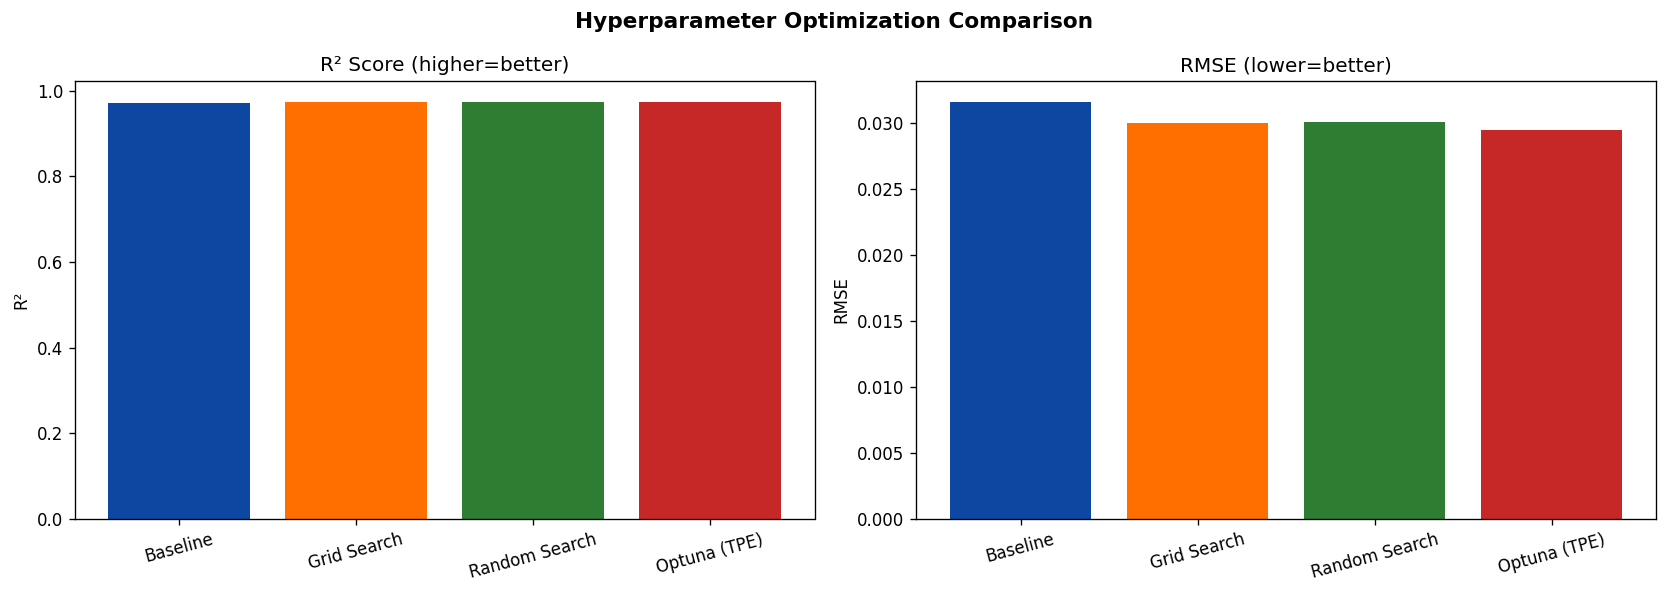

In [8]:
results = pd.DataFrame({
    'Method': ['Baseline', 'Grid Search', 'Random Search', 'Optuna (TPE)'],
    'R2': [base_r2, grid_r2, rand_r2, optuna_r2],
    'RMSE': [base_rmse, grid_rmse, rand_rmse, optuna_rmse]
}).round(4)
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = [COLORS['primary'], COLORS['secondary'], COLORS['accent'], COLORS['highlight']]
axes[0].bar(results['Method'], results['R2'], color=colors)
axes[0].set_title('R² Score (higher=better)'); axes[0].set_ylabel('R²')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=15)

axes[1].bar(results['Method'], results['RMSE'], color=colors)
axes[1].set_title('RMSE (lower=better)'); axes[1].set_ylabel('RMSE')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=15)

plt.suptitle('Hyperparameter Optimization Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/proj1_printer_hpo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

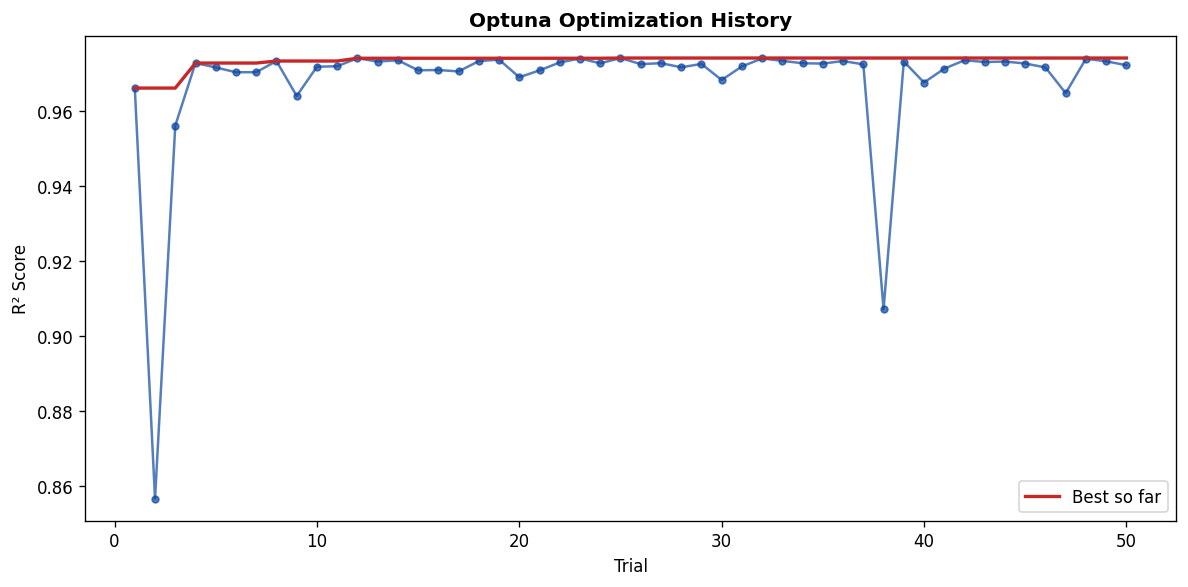

Notebook complete.


In [9]:
# Optuna optimization history
fig, ax = plt.subplots(figsize=(10, 5))
trials = [t.value for t in study.trials]
ax.plot(range(1, len(trials)+1), trials, 'o-', markersize=4, color=COLORS['primary'], alpha=0.7)
ax.plot(range(1, len(trials)+1), np.maximum.accumulate(trials), color=COLORS['highlight'], linewidth=2, label='Best so far')
ax.set_xlabel('Trial'); ax.set_ylabel('R² Score')
ax.set_title('Optuna Optimization History', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../assets/proj1_printer_optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Notebook complete.')